<a href="https://colab.research.google.com/github/AnshSharma16/Machine-learning-with-Python-Projects/blob/main/TitanicSurvivalClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
from google.colab import files
upload=files.upload()

Saving tested.csv to tested (2).csv


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df=pd.read_csv('tested.csv')

In [70]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [71]:
(df.isnull().sum()/len(df)*100)

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [72]:
df.drop('Cabin',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)
df.drop('Ticket',axis=1,inplace=True)
df.drop('PassengerId',axis=1,inplace=True)

In [73]:
for column in df.columns:
  if df[column].dtype=='object':
    print(column,':',(df[column]).unique())


Sex : ['male' 'female']
Embarked : ['Q' 'S' 'C']


In [74]:
(df.isnull().sum()/len(df)*100)

,0
Survived,0.000000
Pclass,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Fare,0.239234
Embarked,0.000000


In [75]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


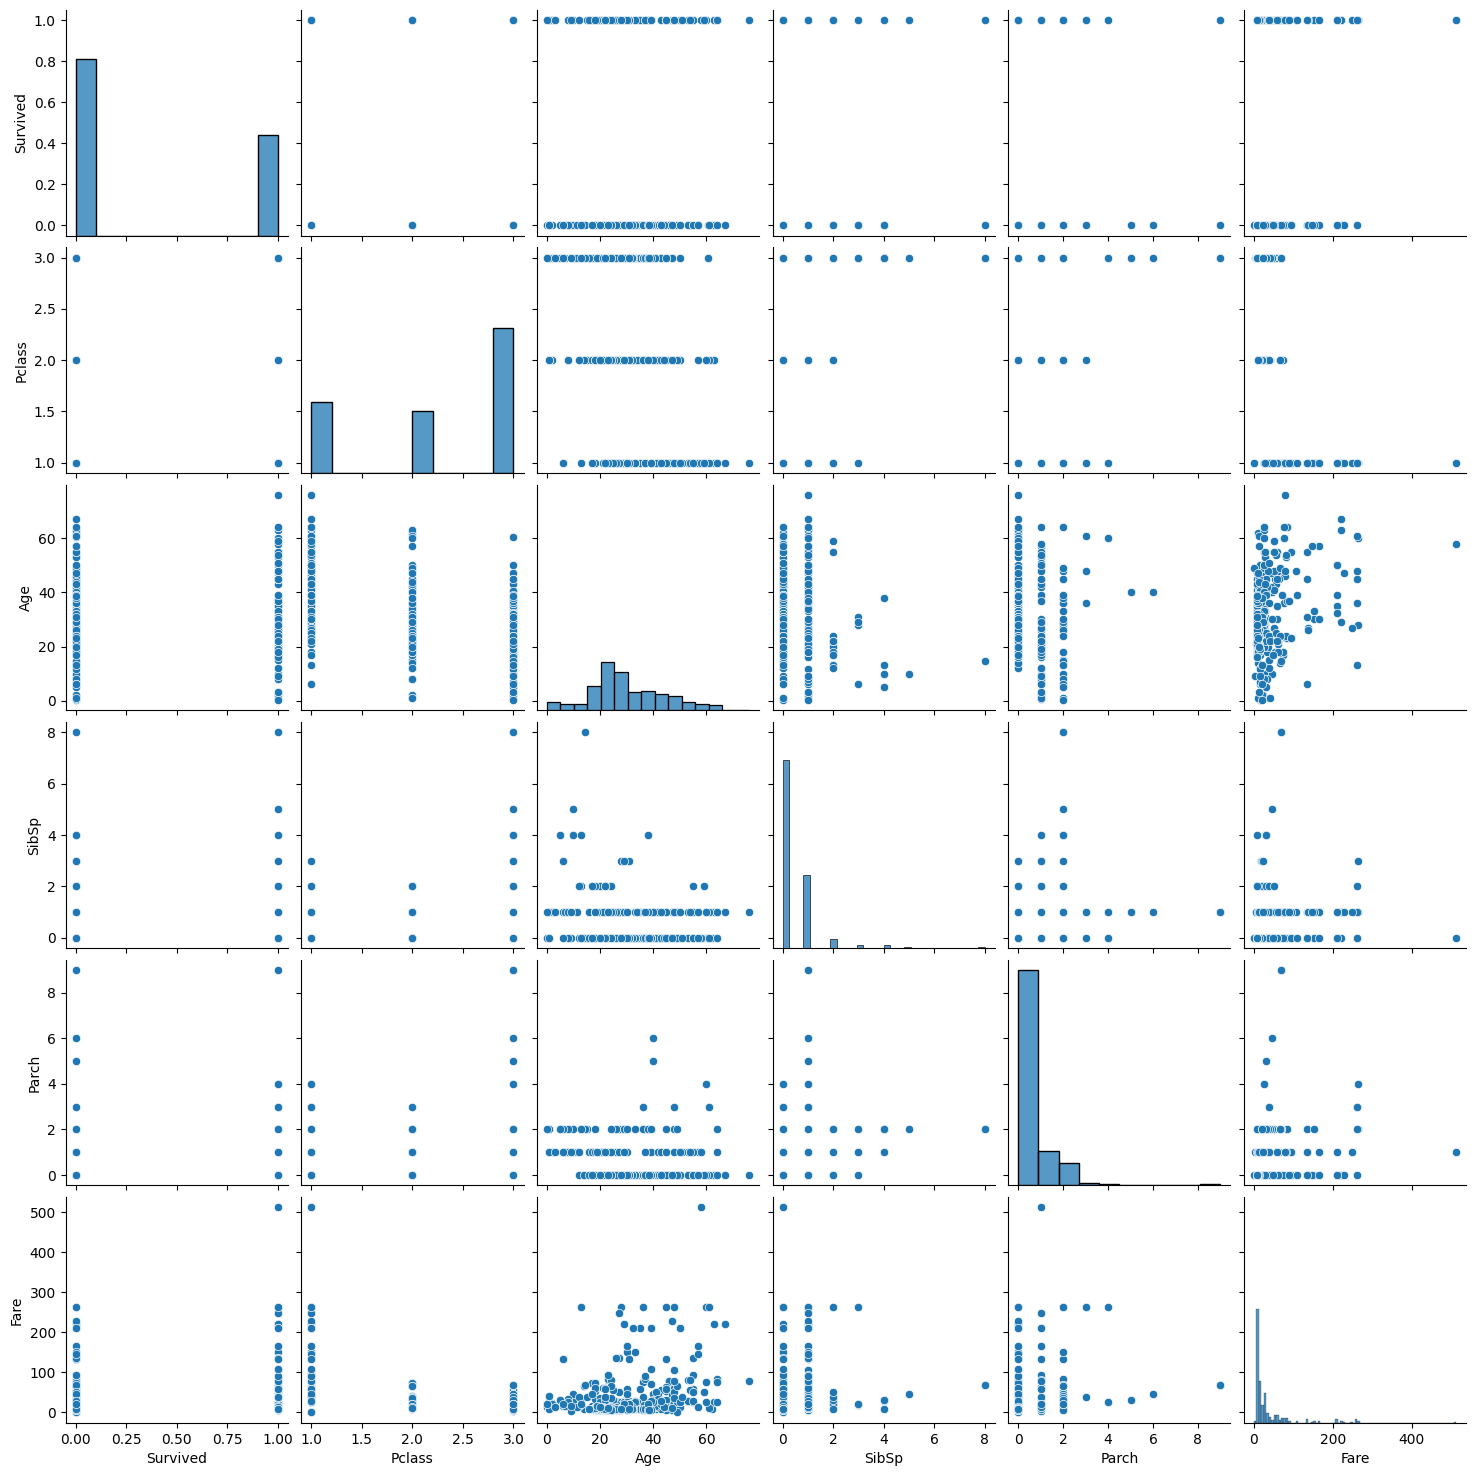

In [76]:
sns.pairplot(df)
plt.show()

In [77]:
df['Age-mean']=df['Age'].fillna(df['Age'].mean())
df['Age-median']=df['Age'].fillna(df['Age'].median())
df['Age-interpolate']=df['Age'].interpolate(method='linear',limit_direction='forward',axis=0)

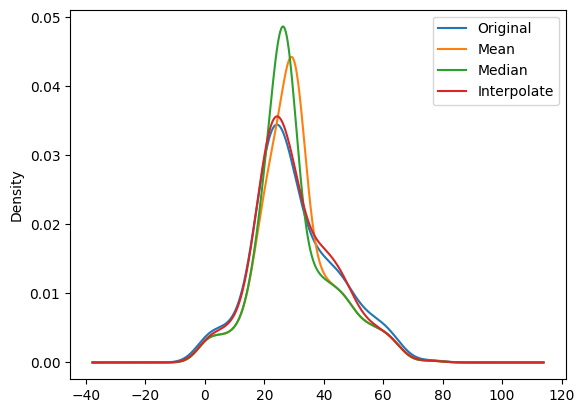

In [78]:
df['Age'].plot(kind='kde', label='Original')
df['Age-mean'].plot(kind='kde', label='Mean')
df['Age-median'].plot(kind='kde', label='Median')
df['Age-interpolate'].plot(kind='kde', label='Interpolate')
plt.legend()
plt.show()

In [79]:
df.drop('Age-mean',axis=1,inplace=True)

In [80]:
df['Age']=df['Age-interpolate']

In [81]:
df.drop('Age-median',axis=1,inplace=True)
df.drop('Age-interpolate',axis=1,inplace=True)

In [82]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


In [83]:
df['Fare']=df['Fare'].interpolate(method='linear', limit_direction='forward',axis=0)

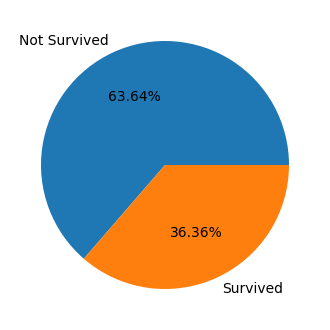

In [84]:
plt.figure(figsize=(4,6))
plt.pie(df['Survived'].value_counts(),labels=['Not Survived','Survived'],autopct='%1.2f%%')
plt.show()

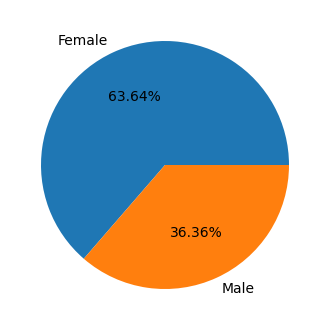

In [85]:
plt.figure(figsize=(4,6))
plt.pie(df['Sex'].value_counts(),labels=['Female','Male'],autopct='%1.2f%%')
plt.show()

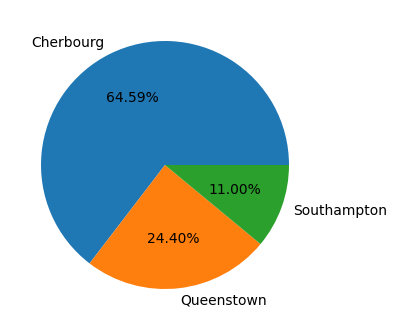

In [86]:
plt.figure(figsize=(4,6))
plt.pie(df['Embarked'].value_counts(),labels=['Cherbourg','Queenstown','Southampton'],autopct='%1.2f%%')
plt.show()

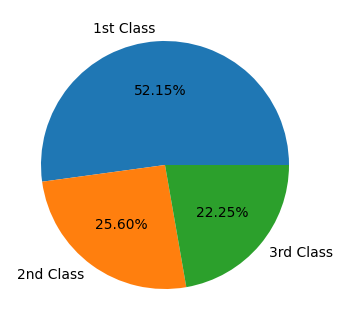

In [87]:
plt.figure(figsize=(4,6))
plt.pie(df['Pclass'].value_counts(),labels=['1st Class','2nd Class','3rd Class'],autopct='%1.2f%%')
plt.show()

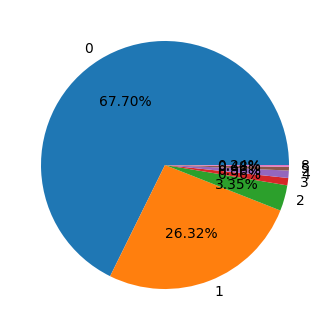

In [88]:
plt.figure(figsize=(4,6))
plt.pie(df['SibSp'].value_counts(),labels=['0','1','2','3','4','5','8'],autopct='%1.2f%%')
plt.show()

<ipython-input-89-1d5075c65da9>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set2')


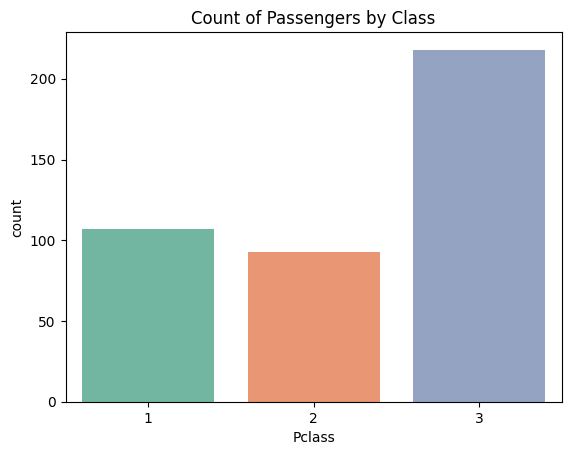

In [89]:
sns.countplot(x='Pclass', data=df, palette='Set2')
plt.title('Count of Passengers by Class')
plt.show()

<ipython-input-90-7722f09ac721>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2')


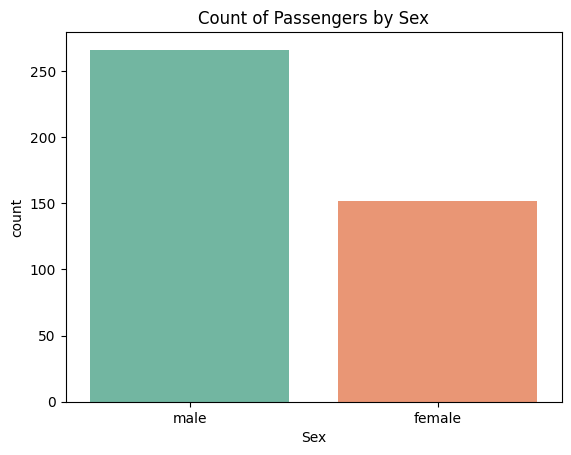

In [90]:
sns.countplot(x='Sex', data=df, palette='Set2')
plt.title('Count of Passengers by Sex')
plt.show()

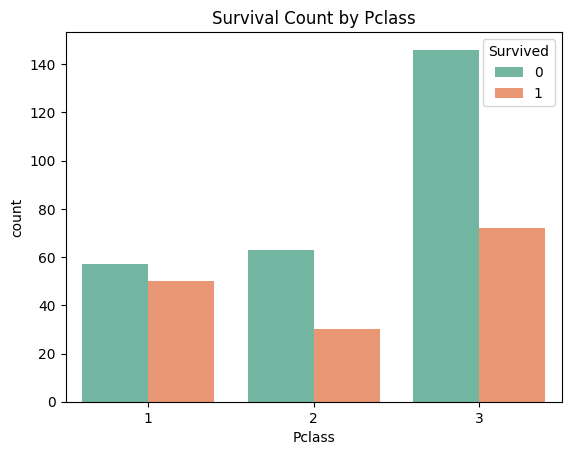

In [91]:
sns.countplot(x='Pclass', hue='Survived',data=df, palette='Set2')
plt.title('Survival Count by Pclass')
plt.show()

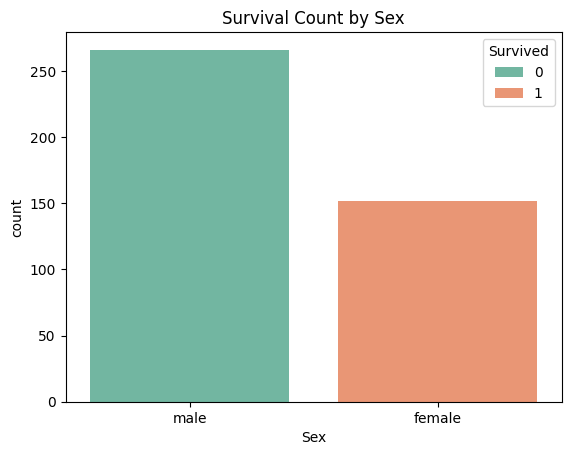

In [92]:
sns.countplot(x='Sex', hue='Survived',data=df, palette='Set2')
plt.title('Survival Count by Sex')
plt.show()

<ipython-input-93-b6fcc7d43226>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Pclass', y='Age', data=df, palette='viridis')


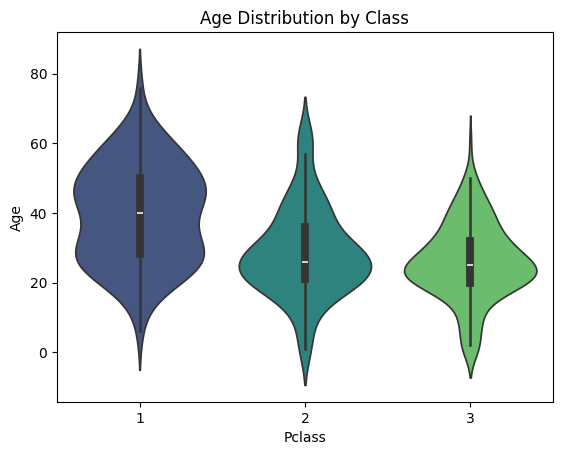

In [93]:
sns.violinplot(x='Pclass', y='Age', data=df, palette='viridis')
plt.title('Age Distribution by Class')
plt.show()

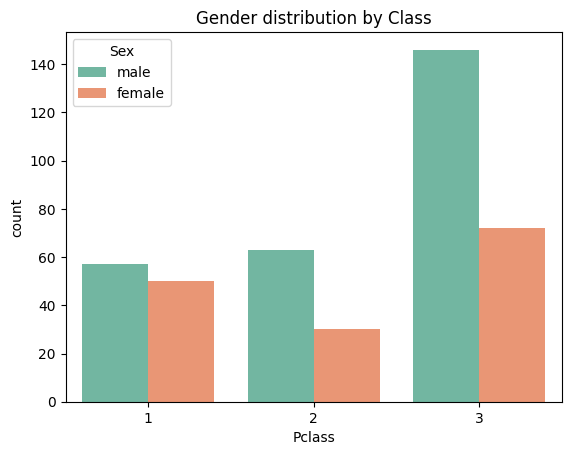

In [94]:
sns.countplot(x='Pclass',hue='Sex', data=df, palette='Set2')
plt.title('Gender distribution by Class')
plt.show()

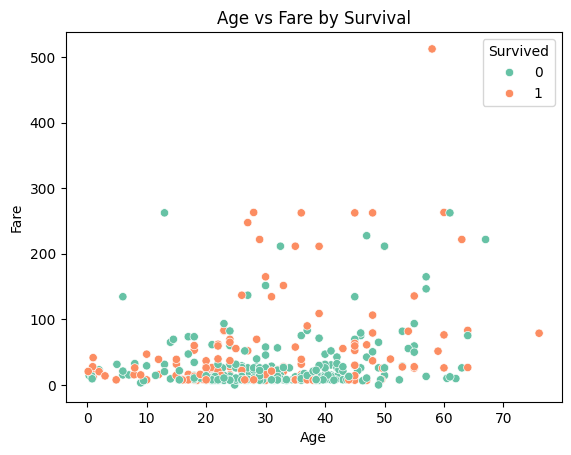

In [95]:
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived', palette='Set2')
plt.title('Age vs Fare by Survival')
plt.show()

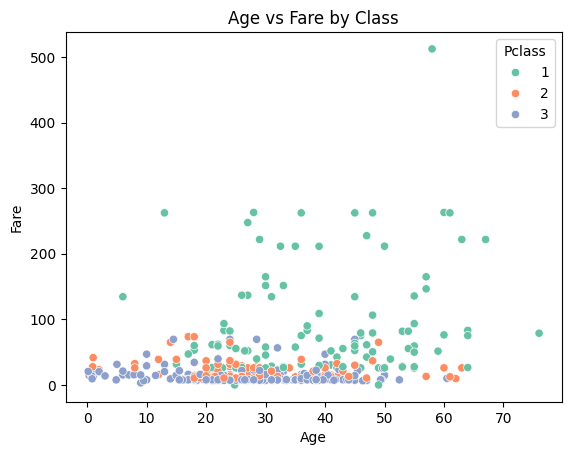

In [96]:
sns.scatterplot(x='Age', y='Fare', data=df, hue='Pclass', palette='Set2')
plt.title('Age vs Fare by Class')
plt.show()

In [97]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=df.apply(le.fit_transform)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,2,1,68,0,0,24,1
1,1,2,0,94,1,0,5,2
2,0,1,1,112,0,0,41,1
3,0,2,1,52,0,0,34,2
4,1,2,0,39,1,1,47,2


In [99]:
from sklearn.model_selection import train_test_split
x=df.drop('Survived',axis=1)
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [150]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [149]:
y_pred_dtc=dt.predict(x_test)

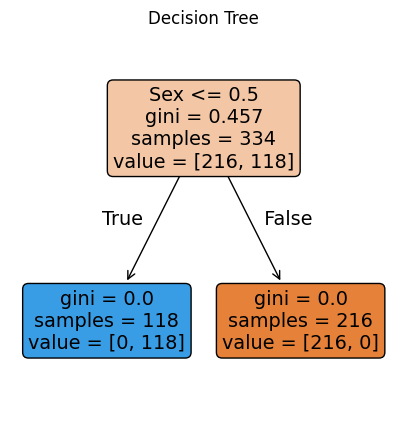

In [111]:
plt.figure(figsize=(5,5))
plot_tree(dt,filled=True,feature_names=x.columns,rounded=True)
plt.title('Decision Tree')
plt.show()

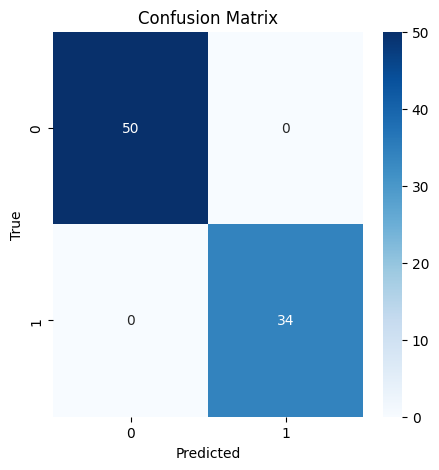

In [121]:
plt.figure(figsize=(5,5))
cm=confusion_matrix(y_test,y_pred_dtc)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [130]:
accuracy=accuracy_score(y_test,y_pred_dtc)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_dtc)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [147]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [148]:
y_pred_lr=lr.predict(x_test)

In [132]:
accuracy=accuracy_score(y_test,y_pred_lr)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_lr)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



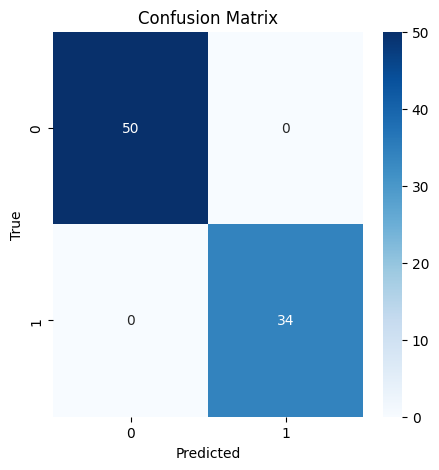

In [133]:
cm=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [142]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [143]:
y_pred_rfc=rf.predict(x_test)

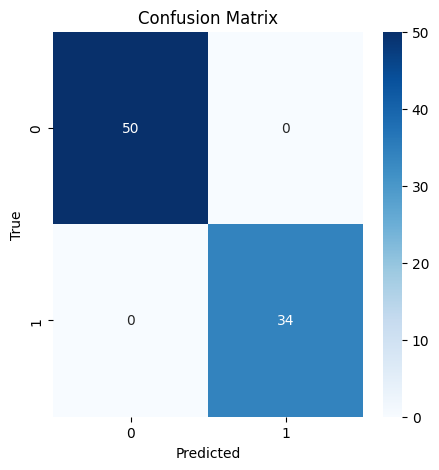

In [135]:
plt.figure(figsize=(5,5))
cm=confusion_matrix(y_test,y_pred_rfc)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [136]:
accuracy=accuracy_score(y_test,y_pred_rfc)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_rfc)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [151]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)

SVC()

In [152]:
y_pred_svm=svm.predict(x_test)

In [138]:
accuracy=accuracy_score(y_test,y_pred_svm)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_svm)
print('Classification Report:\n',classification_rep)

Accuracy: 0.6190476190476191
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.96      0.75        50
           1       0.67      0.12      0.20        34

    accuracy                           0.62        84
   macro avg       0.64      0.54      0.47        84
weighted avg       0.64      0.62      0.53        84



In [140]:
from sklearn.ensemble import VotingClassifier
vc=VotingClassifier(estimators=[('dt',dt),('lr',lr),('rf',rf),('svm',svm)],voting='hard')
vc.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('dt', DecisionTreeClassifier()),
                             ('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svm', SVC())])

In [153]:
y_pred_vc=vc.predict(x_test)

In [154]:
accuracy=accuracy_score(y_test,y_pred_vc)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_vc)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [160]:
from sklearn.ensemble import BaggingClassifier
bc = BaggingClassifier(
    estimator=RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=1,
        min_samples_split=2,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
        verbose= 1,
        max_features=1.0,
        oob_score=True,
    ),
    n_estimators=100,
    random_state=42,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    verbose=1  ,
    oob_score=True,
    bootstrap_features=False,
    warm_start=False,

)

In [161]:
bc.fit(x_train,y_train)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   28.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n

BaggingClassifier(estimator=RandomForestClassifier(max_depth=1,
                                                   max_features=1.0, n_jobs=-1,
                                                   oob_score=True,
                                                   random_state=42, verbose=1),
                  max_samples=0.8, n_estimators=100, n_jobs=-1, oob_score=True,
                  random_state=42, verbose=1)

In [162]:
y_pred_bc=bc.predict(x_test)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    6.7s finished


In [163]:
accuracy=accuracy_score(y_test,y_pred_bc)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_bc)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [164]:
from sklearn.ensemble import StackingClassifier
sc=StackingClassifier(estimators=[('dt',dt),('lr',lr),('rf',rf),('svm',svm)],final_estimator=LogisticRegression())
sc.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(estimators=[('dt', DecisionTreeClassifier()),
                               ('lr', LogisticRegression()),
                               ('rf', RandomForestClassifier()),
                               ('svm', SVC())],
                   final_estimator=LogisticRegression())

In [165]:
y_pred_sc=sc.predict(x_test)

In [166]:
accuracy=accuracy_score(y_test,y_pred_sc)
print('Accuracy:',accuracy)
classification_rep=classification_report(y_test,y_pred_sc)
print('Classification Report:\n',classification_rep)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

